# Critical Evaluation of *"A Subset Feature Elimination Mechanism for Intrusion Detection System"*

**Course:** Data Science in Cyber — Final Project (Dr. Uri Itai)
**Author:** Adam Karain (ID 318407889)
**Date:** June 2026

**Source article:** H. Nkiama, S. Z. Mohd Said and M. Saidu, "A Subset Feature Elimination Mechanism for Intrusion Detection System," *IJACSA*, vol. 7, no. 4, 2016 — [PDF](https://thesai.org/Downloads/Volume7No4/Paper_19-A_Subset_Feature_Elimination_Mechanism_for_Intrusion_Detection_System.pdf)
**Reference implementation:** [CynthiaKoopman/Network-Intrusion-Detection](https://github.com/CynthiaKoopman/Network-Intrusion-Detection)
**Dataset:** NSL-KDD — [defcom17/NSL_KDD](https://github.com/defcom17/NSL_KDD) (copies of the required files are included in `data/`)

## 1. Introduction

Network Intrusion Detection Systems (IDS) classify network traffic as benign or malicious. The article evaluated here argues that most of the 41 NSL-KDD features are redundant, and proposes a feature-selection pipeline — univariate ANOVA filtering followed by Recursive Feature Elimination (RFE) with a decision-tree classifier — applied separately to each of the four attack classes (DoS, Probe, R2L, U2R). The authors report that 11–15 selected features are enough to reach roughly **99.7–99.9% accuracy, precision and recall**, while cutting training time by an order of magnitude.

The problem matters: an IDS that is accurate but slow cannot keep up with modern traffic volumes, and an IDS that misses attacks is worse than none, because it creates false confidence. Feature selection promises to address the first concern without sacrificing the second — *if* the reported detection quality is real.

This notebook reproduces the article's pipeline and tests its claims:

* **C1** — Feature selection (univariate filter + RFE) improves classification performance.
* **C2** — The per-class detectors achieve ≈99.7–99.9% accuracy, precision and recall.
* **C3** — Feature selection drastically reduces training time.
* **C4** — The resulting model is a sound basis for a practical IDS.

The key methodological question is **what the model is evaluated on**. NSL-KDD ships with an official test set, `KDDTest+`, that deliberately contains attack types absent from the training set. We therefore evaluate every model twice: once the way the article does (within the training distribution), and once on the official test set.

## 2. Setup

Fixed random seeds are used everywhere so that every result in this notebook is reproducible.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                             accuracy_score, f1_score, fbeta_score,
                             matthews_corrcoef, precision_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
DATA_DIR = Path("data")
sns.set_theme(style="whitegrid", palette="muted")

## 3. Data Loading

NSL-KDD is distributed as headerless text files; the official column names are listed in `Field Names.csv`. Each record describes one TCP/UDP/ICMP connection with 41 features, an attack-type label, and a `difficulty` score. We load the full training set (`KDDTrain+`) and the official test set (`KDDTest+`).

In [2]:
feature_names = pd.read_csv(DATA_DIR / "Field Names.csv", header=None)[0].tolist()
COLUMNS = feature_names + ["label", "difficulty"]


def load_split(file_name):
    """Read one NSL-KDD file and attach the official column names."""
    return pd.read_csv(DATA_DIR / file_name, header=None, names=COLUMNS)


train = load_split("KDDTrain+.txt")
test = load_split("KDDTest+.txt")

In [3]:
print(f"Training set: {train.shape[0]:,} rows x {train.shape[1]} columns\n"
      f"Test set:     {test.shape[0]:,} rows x {test.shape[1]} columns")

Training set: 125,973 rows x 43 columns
Test set:     22,544 rows x 43 columns


**First discrepancy.** The article reports 126,620 training and 22,850 test records (its Tables I–III), but the official files contain **125,973** and **22,544**. The difference is small, yet it shows that the article's bookkeeping does not match the published data — a useful reminder to verify everything that follows.

In [4]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


**Columns and index.** The index is a plain row number, which is appropriate: each record is an independent connection summary, so no natural key exists. The column names follow the official field list (duration, protocol, service, flag, byte counts, content counters, and 2-second/host-based traffic-window statistics), so the schema is sensible and matches the documentation. `label` holds the attack type and `difficulty` is evaluation metadata, not a traffic feature — both are excluded from the design matrix later.

In [5]:
train.dtypes.value_counts().rename("columns").to_frame()

,columns
int64,24
float64,15
object,4


**Feature types.** Of the 43 columns, 38 features are numeric (counters, rates in [0, 1], and binary indicators stored as integers), three are nominal strings (`protocol_type`, `service`, `flag` — encoded in §5), and the remaining two object/int columns are `label` and `difficulty`. There are no date or free-text columns.

### 3.1 Attack categories

The 39 attack-type labels are grouped into four standard categories (DoS, Probe, R2L, U2R), following the article and the NSL-KDD documentation. The mapping below also covers the attack types that appear **only** in the test set.

In [6]:
ATTACK_CATEGORY = {
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS", "smurf": "DoS",
    "teardrop": "DoS", "apache2": "DoS", "udpstorm": "DoS", "processtable": "DoS",
    "worm": "DoS", "mailbomb": "DoS",
    "satan": "Probe", "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe",
    "mscan": "Probe", "saint": "Probe",
    "guess_passwd": "R2L", "ftp_write": "R2L", "imap": "R2L", "phf": "R2L",
    "multihop": "R2L", "warezmaster": "R2L", "warezclient": "R2L", "spy": "R2L",
    "xlock": "R2L", "xsnoop": "R2L", "snmpguess": "R2L", "snmpgetattack": "R2L",
    "httptunnel": "R2L", "sendmail": "R2L", "named": "R2L",
    "buffer_overflow": "U2R", "loadmodule": "U2R", "rootkit": "U2R", "perl": "U2R",
    "sqlattack": "U2R", "xterm": "U2R", "ps": "U2R",
    "normal": "normal",
}

train["category"] = train["label"].map(ATTACK_CATEGORY)
test["category"] = test["label"].map(ATTACK_CATEGORY)
assert train["category"].notna().all() and test["category"].notna().all()

In [7]:
CATEGORY_ORDER = ["normal", "DoS", "Probe", "R2L", "U2R"]
category_counts = pd.concat(
    [train["category"].value_counts(), test["category"].value_counts()],
    axis=1, keys=["train", "test"]).loc[CATEGORY_ORDER]
category_counts

,train,test
category,,
normal,67343,9711
DoS,45927,7460
Probe,11656,2421
R2L,995,2885
U2R,52,67


The two rare classes are strikingly small: **R2L has 995 and U2R only 52 training records**, against 67,343 normal connections. Note also the proportions: R2L is 0.8% of the training set but 12.8% of the test set. We return to this imbalance in the EDA.

In [8]:
novel_attacks = sorted(set(test["label"]) - set(train["label"]))
novel_share = test.loc[test["category"] != "normal", "label"].isin(novel_attacks).mean()
print(f"{len(novel_attacks)} attack types appear only in the test set:\n{novel_attacks}\n"
      f"They account for {novel_share:.1%} of all attack records in KDDTest+.")

17 attack types appear only in the test set:
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']
They account for 29.2% of all attack records in KDDTest+.


This is **by design**. Tavallaee et al. (2009), who created NSL-KDD, built `KDDTest+` so that a meaningful share of its attacks are types never seen during training, precisely to measure whether a detector generalizes beyond the attack catalog it was trained on. Any evaluation that never touches `KDDTest+` silently skips this question — keep this in mind for Section 7.

### 3.2 Data quality inspection

In [9]:
print(f"Missing values (both splits): {int(train.isna().sum().sum() + test.isna().sum().sum())}\n"
      f"Duplicate training rows: {train.duplicated().sum()}\n"
      f"Duplicate test rows: {test.duplicated().sum()}")

Missing values (both splits): 0
Duplicate training rows: 0
Duplicate test rows: 0


No missing values and no duplicates — as expected, since removing the massive duplication of the original KDD'99 was the main reason NSL-KDD was created. No imputation or deduplication is needed.

In [10]:
constant_features = train[feature_names].nunique().loc[lambda counts: counts == 1].index.tolist()
print(f"Constant features in the training set: {constant_features}")

Constant features in the training set: ['num_outbound_cmds']


`num_outbound_cmds` equals zero in every record of both splits, so it carries no information and is dropped. Together with `label`, `category` and `difficulty`, this is the only column removed before modelling; there are no duplicated feature columns (all pairwise-identical checks come up empty, see the redundancy analysis in §4.4 for *near*-duplicates).

### 3.3 Temporal analysis

NSL-KDD contains **no timestamps**: records are connection summaries in no chronological order, so a time-based split or trend analysis is impossible. The temporal dimension instead lives *inside* the features: `count`, `srv_count` and the error-rate features are computed over a 2-second window preceding each connection, and the `dst_host_*` features over a 100-connection window per destination host. Checking these against domain knowledge:

In [11]:
window_features = ["count", "srv_count", "serror_rate", "same_srv_rate", "dst_host_count"]
train.groupby("category")[window_features].mean().round(2).loc[CATEGORY_ORDER]

,count,srv_count,serror_rate,same_srv_rate,dst_host_count
category,,,,,
normal,22.52,27.69,0.01,0.97,147.43
DoS,178.09,32.66,0.75,0.19,244.60
Probe,77.05,10.94,0.05,0.70,145.20
R2L,1.30,2.46,0.01,1.00,89.04
U2R,5.81,1.27,0.04,0.93,47.77


The window features behave exactly as networking knowledge predicts: **DoS** floods produce many connections per window (`count` ≈ 178, eight times the normal rate) with a high SYN-error rate (`serror_rate` ≈ 0.75 — half-open connections, the signature of a SYN flood); **Probe** scans also drive `count` up while spreading across services; **R2L and U2R look almost identical to normal traffic** in these aggregates, because they consist of a few application-layer sessions rather than high-volume floods. This already hints at which classes will be hard to detect.

## 4. Exploratory Data Analysis

### 4.1 Class balance and prevalence

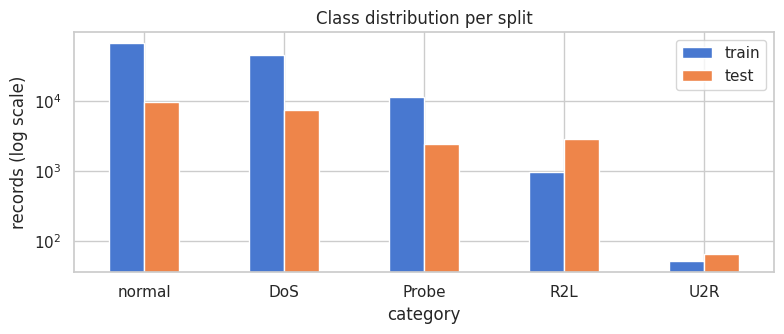

In [12]:
ax = category_counts.plot.bar(figsize=(8, 3.5), logy=True, rot=0)
ax.set_ylabel("records (log scale)")
ax.set_title("Class distribution per split")
plt.tight_layout()
plt.show()

In [13]:
prevalence = category_counts.div(category_counts.sum()).mul(100).round(2)
prevalence.rename(columns=lambda split: f"{split} (%)")

,train (%),test (%)
category,,
normal,53.46,43.08
DoS,36.46,33.09
Probe,9.25,10.74
R2L,0.79,12.80
U2R,0.04,0.30


**Class-imbalance analysis.** Attack prevalence differs sharply between splits and classes:

* **U2R is 0.04% of the training data** — 52 records to learn from. No classifier can characterize "privilege escalation" from 52 examples; this is a sampling problem in the dataset itself.
* **R2L is 0.8% of training but 12.8% of the test set** (and most test R2L types are new). The class prior shifts by a factor of ~16 between fit and deployment.
* The real-world meaning: in production traffic, attacks are rare events, so plain accuracy is dominated by the majority class. NSL-KDD's test set is the opposite extreme (57% attacks), which is equally unrepresentative; either way, accuracy alone is uninformative — §7 shows a U2R detector with 99.5% accuracy that misses two-thirds of U2R attacks.

**Did the authors address this?** No. The article reports accuracy as its headline metric, uses no class weighting or resampling, and never mentions the train/test prevalence gap. This is the first substantive weakness of the source.

### 4.2 Continuous features and outliers

The traffic counters span many orders of magnitude, so they are plotted on a log scale.

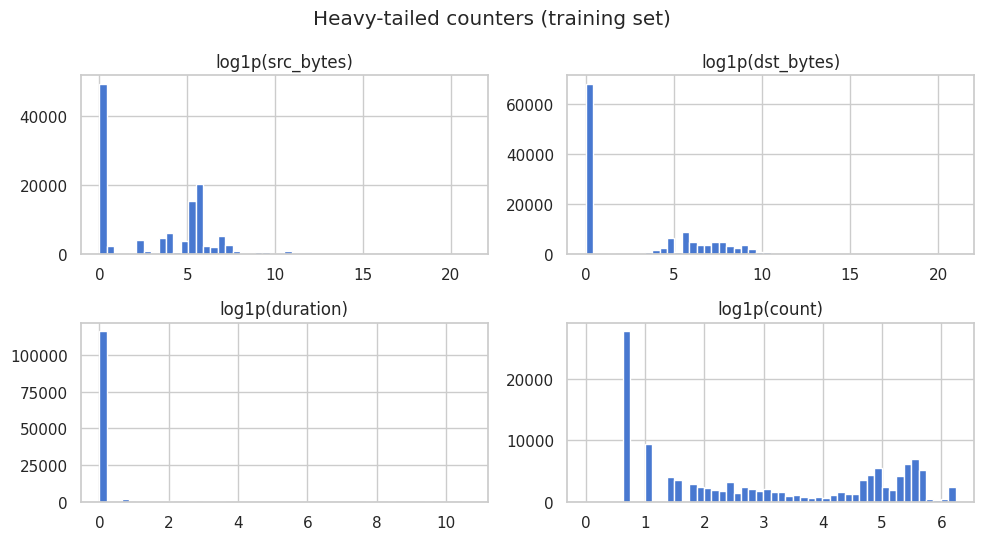

In [14]:
heavy_tailed = ["src_bytes", "dst_bytes", "duration", "count"]
fig, axes = plt.subplots(2, 2, figsize=(10, 5.5))
for feature, ax in zip(heavy_tailed, axes.ravel()):
    ax.hist(np.log1p(train[feature]), bins=50)
    ax.set_title(f"log1p({feature})")
fig.suptitle("Heavy-tailed counters (training set)")
plt.tight_layout()
plt.show()

In [15]:
outlier_summary = train[heavy_tailed].describe(percentiles=[0.5, 0.99]).T
outlier_summary[["50%", "99%", "max"]].astype(int)

,50%,99%,max
src_bytes,44,54540,1379963888
dst_bytes,0,25519,1309937401
duration,0,9590,42908
count,14,511,511


**Outlier analysis.** The distributions are zero-inflated and extremely heavy-tailed: the median of `src_bytes` is 44 bytes while the maximum is ≈1.4 **GB** — more than four orders of magnitude above the 99th percentile. Crucially, these outliers are **not measurement noise but attack behavior** (flood volumes, large exfiltration payloads, very long sessions), so removing or winsorizing them would delete the signal we want to detect. Instead the heavy tails inform two methodological choices: a rank-based correlation measure (§4.4) and a log transform for the scale-sensitive linear model (§5).

### 4.3 Categorical features (crosstab analysis)

In [16]:
pd.crosstab(train["protocol_type"], train["category"], normalize="columns").round(3)[CATEGORY_ORDER]

category,normal,DoS,Probe,R2L,U2R
protocol_type,,,,,
icmp,0.019,0.062,0.355,0.0,0.000
tcp,0.796,0.919,0.502,1.0,0.942
udp,0.185,0.019,0.143,0.0,0.058


The protocol mix per class matches domain knowledge: DoS is mostly TCP (the `neptune` SYN flood) with a visible ICMP share (the `smurf` echo-reply flood); probes use ICMP sweeps far more than any other class; R2L and U2R are almost purely TCP, as expected for application-layer attacks (logins, shells).

In [17]:
pd.crosstab(train["flag"], train["category"], normalize="columns").round(3)[CATEGORY_ORDER]

category,normal,DoS,Probe,R2L,U2R
flag,,,,,
OTH,0.000,0.000,0.003,0.000,0.000
REJ,0.040,0.123,0.246,0.000,0.000
RSTO,0.003,0.026,0.007,0.046,0.019
RSTOS0,0.000,0.000,0.009,0.000,0.000
RSTR,0.002,0.002,0.187,0.005,0.000
S0,0.005,0.748,0.013,0.000,0.000
S1,0.005,0.000,0.000,0.001,0.000
S2,0.002,0.000,0.000,0.001,0.000
S3,0.001,0.000,0.000,0.003,0.000


The TCP status flag is even more telling: **79% of DoS connections end in `S0`** (SYN sent, nothing came back — a half-open connection, the textbook SYN-flood signature), probes concentrate in `REJ`/`RSTR` (rejected or reset scans), while **R2L traffic ends in `SF` (a normally completed connection) 97% of the time — exactly like benign traffic**. The categorical features confirm the §3.3 picture: volumetric attacks are easy, stealthy ones are not.

### 4.4 Correlation analysis

**Choice of correlation measure.** We studied three options:

* **Pearson** measures *linear* association and assumes approximately well-behaved (finite-variance, outlier-free) variables. With features spanning nine orders of magnitude, a single extreme record can dominate the statistic.
* **Spearman** is Pearson on ranks: it captures any *monotonic* relationship, is invariant to monotone transforms (so `src_bytes` and `log1p(src_bytes)` give identical values) and is robust to the outliers documented above.
* **Kendall** estimates the probability of concordance; it is preferred for small samples or when many ties distort Spearman. With *n* = 125,973 its extra robustness adds little, at a higher computational cost.

**Decision: Spearman** is the primary measure — the data are heavy-tailed, outlier-rich and full of saturated rates, which violates Pearson's working assumptions, while the sample is far too large for Kendall to add value. Pearson is shown once below to demonstrate the difference, and one more caveat applies: with *n* ≈ 126,000, even ρ = 0.01 is "statistically significant," so we reason about **effect size (practical significance), not p-values**.

In [18]:
pearson = train["src_bytes"].corr(train["dst_bytes"])
spearman = train["src_bytes"].corr(train["dst_bytes"], method="spearman")
print(f"src_bytes vs dst_bytes -- Pearson: {pearson:+.3f}, Spearman: {spearman:+.3f}")

src_bytes vs dst_bytes -- Pearson: +0.000, Spearman: +0.700


A textbook illustration: Pearson reports essentially no association because a handful of gigabyte-scale records crush the covariance, while Spearman reveals the strong monotonic relationship one expects between request and response sizes. Conclusions below rely on Spearman.

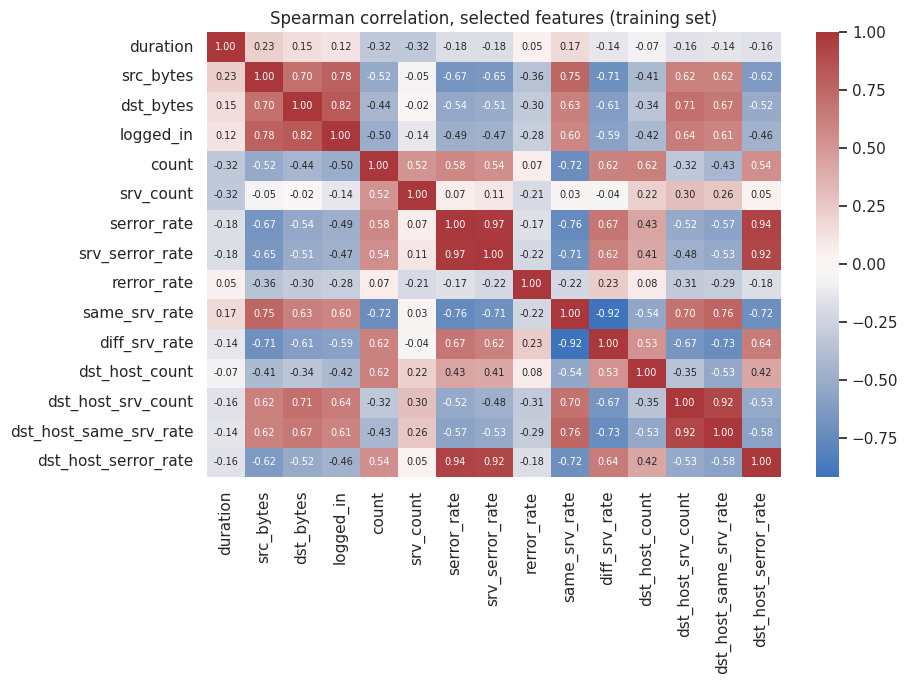

In [19]:
correlation_features = ["duration", "src_bytes", "dst_bytes", "logged_in", "count",
                        "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
                        "same_srv_rate", "diff_srv_rate", "dst_host_count",
                        "dst_host_srv_count", "dst_host_same_srv_rate",
                        "dst_host_serror_rate"]
spearman_matrix = train[correlation_features].corr(method="spearman")
plt.figure(figsize=(9.5, 7))
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            annot_kws={"size": 7})
plt.title("Spearman correlation, selected features (training set)")
plt.tight_layout()
plt.show()

In [20]:
upper_triangle = spearman_matrix.where(np.triu(np.ones_like(spearman_matrix, dtype=bool), k=1))
redundant_pairs = upper_triangle.stack().loc[lambda corr: corr.abs() > 0.9].round(3)
redundant_pairs.rename("Spearman rho").to_frame()

Spearman rho
serror_rate        srv_serror_rate                0.973
                   dst_host_serror_rate           0.936
srv_serror_rate    dst_host_serror_rate           0.919
same_srv_rate      diff_srv_rate                 -0.920
dst_host_srv_count dst_host_same_srv_rate         0.919

**Redundancy in the system.** Several feature pairs are near-duplicates: the SYN-error rate is measured three times at different aggregation levels (`serror_rate`, `srv_serror_rate`, `dst_host_serror_rate`, pairwise ρ ≈ 0.92–0.97), `same_srv_rate` and `diff_srv_rate` are near mirror images (ρ = −0.92), and `dst_host_srv_count` largely repeats `dst_host_same_srv_rate` (ρ = 0.92).

*How to spot it:* exactly as done here — screen the correlation matrix for |ρ| > 0.9, or use variance-inflation factors / hierarchical clustering on 1 − |ρ| for groups rather than pairs.

*How to tackle it:* keep one representative per cluster, use regularization (for linear models), or let a wrapper method such as RFE prune the copies. Redundancy barely hurts tree *accuracy*, but it dilutes feature-importance scores, slows training, and inflates the dimensionality that the article uses to motivate feature selection in the first place — so the article's premise that 41 features contain substantial redundancy is, in fairness, **correct**.

In [21]:
numeric_features = [name for name in feature_names
                    if name not in ["protocol_type", "service", "flag", "num_outbound_cmds"]]
is_attack_train = (train["category"] != "normal").astype(int)
target_correlation = train[numeric_features].corrwith(is_attack_train, method="spearman")
target_correlation.reindex(target_correlation.abs().sort_values(ascending=False).index).head(10).round(3).rename("Spearman rho vs is_attack").to_frame()

,Spearman rho vs is_attack
dst_bytes,-0.752
same_srv_rate,-0.735
src_bytes,-0.711
logged_in,-0.690
dst_host_srv_count,-0.686
diff_srv_rate,0.677
serror_rate,0.655
dst_host_same_srv_rate,-0.651
dst_host_serror_rate,0.638
srv_serror_rate,0.630


The strongest monotone associations with the attack label are all consistent with the crosstabs: attacks rarely receive a substantial response payload (`dst_bytes`, ρ = −0.75 — floods and scans get nothing back), their windows are spread across many different services (`same_srv_rate` negative, `diff_srv_rate` positive), they rarely reach a logged-in state (`logged_in`, ρ = −0.69), and they trip the SYN-error counters. Two caveats: these are |ρ| ≈ 0.6–0.75 effects — strong and practically significant, not just statistically so — and they describe a training distribution dominated by `neptune` and `smurf`. Whether they transfer to unseen attack types is precisely what Section 7 tests.

## 5. Feature Engineering

Four transformations are applied, each with an explicit rationale:

1. **Dropping non-features** — `num_outbound_cmds` (constant, §3.2), `label`/`category` (targets) and `difficulty` (evaluation metadata; using it would leak information about how hard a record is to classify).
2. **`log1p` on the heavy-tailed counters** (`src_bytes`, `dst_bytes`, `duration`, `count`) — compresses nine orders of magnitude so that the linear model is not dominated by a few extreme records. The transform is monotonic, so tree-based models are unaffected — it can only help, not hurt. Evidence of effect: the skewness table below.
3. **One-hot encoding** for `protocol_type`, `service`, `flag` — these are *nominal* with no order, so integer/label encoding would fabricate a false ordering; target encoding was rejected because it injects label information into features and risks leakage under resampling. With 84 categories in total, one-hot keeps the design matrix at a manageable 121 columns, sparse and fully interpretable.
4. **Standardization (z-scores), fitted on the training set only** — required by the distance/gradient-based logistic regression; harmless for trees. Fitting the scaler on test data would leak test statistics into preprocessing. (The reference implementation fits a *separate* scaler on the test set — a small but real protocol flaw we do not reproduce.)

In [22]:
log_transformed = train[heavy_tailed].apply(np.log1p)
pd.DataFrame({"skewness (raw)": train[heavy_tailed].skew(),
              "skewness (log1p)": log_transformed.skew()}).round(1)

,skewness (raw),skewness (log1p)
src_bytes,190.7,0.3
dst_bytes,290.1,0.5
duration,11.9,5.3
count,1.5,0.1


The transform reduces the skewness of the byte counters from ≈190–290 to below 1 — from "a few records dominate the scale" to roughly bell-shaped, exactly the regime in which standardization and linear decision boundaries behave well. `duration` remains moderately skewed (5.3) because most connections are instantaneous; that is genuine structure, not a transformation failure.

In [23]:
CATEGORICAL = ["protocol_type", "service", "flag"]
NON_FEATURES = ["num_outbound_cmds", "label", "difficulty", "category"]


def build_features(frame):
    """Drop non-features, log-compress heavy-tailed counters, one-hot encode."""
    features = frame.drop(columns=NON_FEATURES)
    features[heavy_tailed] = features[heavy_tailed].apply(np.log1p)
    return pd.get_dummies(features, columns=CATEGORICAL, dtype=float)


X_train_raw = build_features(train)
X_test_raw = build_features(test).reindex(columns=X_train_raw.columns, fill_value=0.0)
y_train = (train["category"] != "normal").astype(int)
y_test = (test["category"] != "normal").astype(int)

In [24]:
scaler = StandardScaler().fit(X_train_raw)
X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=X_train_raw.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)
print(f"Design matrices -- train: {X_train.shape}, test: {X_test.shape}\n"
      f"Service categories present only in training: "
      f"{sorted(set(train['service']) - set(test['service']))}")

Design matrices -- train: (125973, 121), test: (22544, 121)
Service categories present only in training: ['aol', 'harvest', 'http_2784', 'http_8001', 'red_i', 'urh_i']


The test matrix is aligned to the training columns with `reindex`: six rare services occur only in training, and their indicator columns are simply zero for every test record — the correct production behavior for "category never seen at inference time."

**Feature selection** is deferred to Section 7, because it *is* the article's contribution and deserves its own treatment. **Dimensionality reduction** (e.g. PCA) is deliberately not used: an IDS analyst must be able to read *why* a connection was flagged ("high SYN-error rate to port 80"), and linear combinations of 121 columns destroy that interpretability while offering trees no accuracy benefit.

## 6. Model Training

**Two evaluation protocols.** Everything in this project hinges on this distinction:

* **Protocol A (the article's logic):** stratified 80/20 random split *within* `KDDTrain+`. Train and validation records then come from the same distribution — statistically the same thing as the article's 10-fold cross-validation.
* **Protocol B (the intended benchmark):** fit on all of `KDDTrain+`, evaluate on the official `KDDTest+`, where 29% of attack records belong to never-seen attack types.

**Three models** are trained as binary detectors (normal vs. attack): logistic regression (a linear baseline), a decision tree (the article's classifier), and a random forest (a stronger ensemble). All share the same preprocessing and seeds.

In [25]:
def evaluate_predictions(y_true, y_pred, y_score):
    """Compute all classification metrics used in this project."""
    return pd.Series({
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "F2": fbeta_score(y_true, y_pred, beta=2),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_score),
    })

In [26]:
def fit_and_evaluate(make_model):
    """Return a fitted model plus its Protocol A and Protocol B metric rows."""
    X_fit, X_val, y_fit, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)
    validation_model = make_model().fit(X_fit, y_fit)
    protocol_a = evaluate_predictions(y_val, validation_model.predict(X_val),
                                      validation_model.predict_proba(X_val)[:, 1])
    final_model = make_model().fit(X_train, y_train)
    protocol_b = evaluate_predictions(y_test, final_model.predict(X_test),
                                      final_model.predict_proba(X_test)[:, 1])
    return final_model, protocol_a, protocol_b

In [27]:
MODEL_FACTORIES = {
    "Logistic Regression": lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": lambda: DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                                    random_state=RANDOM_STATE),
}

fitted_models, protocol_a_rows, protocol_b_rows = {}, {}, {}
for model_name, factory in MODEL_FACTORIES.items():
    fitted_models[model_name], protocol_a_rows[model_name], protocol_b_rows[model_name] = \
        fit_and_evaluate(factory)

In [28]:
pd.DataFrame(protocol_a_rows).T.round(4)

,accuracy,precision,recall,F1,F2,MCC,ROC-AUC
Logistic Regression,0.9729,0.9767,0.9649,0.9707,0.9672,0.9456,0.9965
Decision Tree,0.9984,0.9979,0.9986,0.9983,0.9985,0.9967,0.9984
Random Forest,0.9990,0.9994,0.9986,0.9990,0.9987,0.9981,1.0000


Under Protocol A every model looks superb — the tree-based models exceed 99.6% on *every* metric, fully consistent with the article's reported numbers and with the dozens of NSL-KDD tutorials that stop here.

In [29]:
pd.DataFrame(protocol_b_rows).T.round(4)

,accuracy,precision,recall,F1,F2,MCC,ROC-AUC
Logistic Regression,0.7544,0.9130,0.6284,0.7444,0.6702,0.5572,0.7638
Decision Tree,0.8117,0.9666,0.6931,0.8074,0.7347,0.6665,0.8309
Random Forest,0.7766,0.9687,0.6278,0.7618,0.6753,0.6168,0.9590


Under Protocol B the picture changes completely: **accuracy drops by 18–22 points and recall collapses to 0.62–0.69**, while precision stays above 0.91 — the models almost never cry wolf, they simply *miss a third of the attacks*. The same models, the same preprocessing, the same seeds; the only difference is evaluating on data whose attack mix the models have not memorized. Note how misleading accuracy alone would be here (still 0.75–0.81), and how MCC (0.56–0.67 vs. 0.95–1.00) exposes the gap honestly.

### 6.1 Evaluation metrics: definitions and justification

For a confusion matrix with true/false positives and negatives (TP, FP, TN, FN), an "attack" being the positive class:

* **Accuracy** = (TP+TN)/N — share of correct decisions. Reported *only* because the article uses it as its headline number; with 46–57% attack prevalence across splits it is not absurd here, but it hides the FN/FP composition entirely and would be meaningless at realistic (low) attack rates.
* **Precision** = TP/(TP+FP) — of the alerts raised, how many are real. Low precision means alert fatigue: analysts drown in false alarms and start ignoring the console.
* **Recall (detection rate)** = TP/(TP+FN) — of the real attacks, how many we caught. Every FN is an undetected intrusion; in security this is usually the costlier error.
* **F1** = harmonic mean of precision and recall — a single balance number, used for cross-model comparison.
* **F2** = F-beta with β = 2, weighting recall twice as heavily as precision. We report it because the IDS cost structure is asymmetric: a missed breach (FN) costs incident response, data loss and legal exposure, while a false alarm (FP) costs analyst minutes. β = 2 encodes "recall matters roughly twice as much."
* **MCC** (Matthews correlation) — correlation between predicted and true labels using all four confusion-matrix cells; 1 is perfect, 0 is chance. It is the most honest single number under class imbalance and cannot be gamed by majority-class guessing.
* **ROC-AUC** — probability that a random attack scores above a random normal record; threshold-free, it separates *ranking quality* from *threshold choice*, which proves diagnostic below.

**Omitted metrics, and why:** regression metrics (MAE/MSE/RMSE/R²) do not apply to a classification task; specificity is redundant given the false-positive analysis in §8; F0.5 encodes the opposite (precision-heavy) cost structure to the IDS use case.

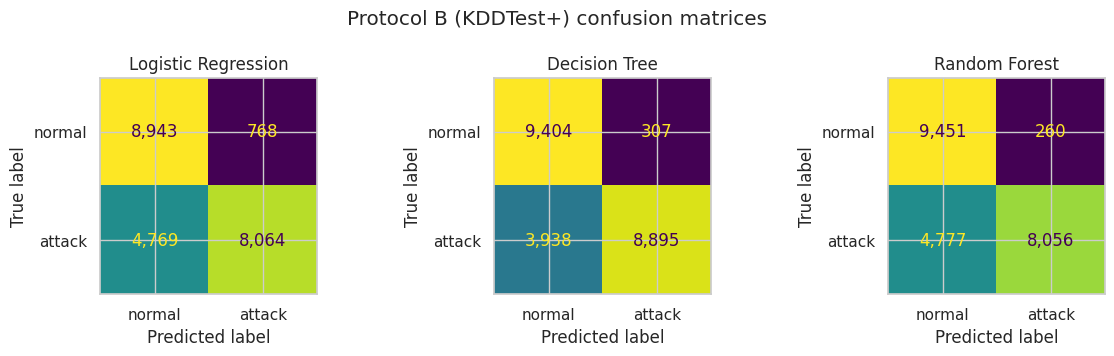

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for (model_name, model), ax in zip(fitted_models.items(), axes):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, colorbar=False,
                                          display_labels=["normal", "attack"],
                                          values_format=",d")
    ax.set_title(model_name)
fig.suptitle("Protocol B (KDDTest+) confusion matrices")
plt.tight_layout()
plt.show()

The confusion matrices make the failure mode concrete: false positives stay in the hundreds (260–770 out of 9,711 normal records), while **false negatives run into the thousands** (3,900–4,800 out of 12,833 attacks). An IDS with this profile feels reassuringly quiet — and is blind to a third of real attacks.

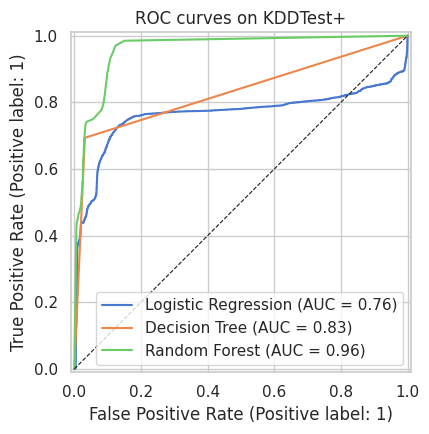

In [31]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for model_name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title("ROC curves on KDDTest+")
plt.tight_layout()
plt.show()

An instructive split result: the random forest *ranks* attacks well (AUC ≈ 0.96) even though its default-threshold recall is only ≈0.63. Its scores carry real signal, but the 0.5 threshold — implicitly calibrated on the training distribution — sits in the wrong place once the attack mix shifts. Lowering the threshold would trade false positives for recall along this curve; under distribution shift, **threshold calibration breaks before ranking does**. The decision tree, by contrast, offers no such ranking reserve (AUC ≈ 0.83): its problem is the model, not the threshold.

## 7. Reproducing the Article's Per-Class Protocol

The article's actual pipeline, per attack class: keep normal traffic plus one attack category, select 11–15 features with RFE around a decision tree, then report 10-fold cross-validation metrics. We reproduce it faithfully, with two declared deviations made for compute budget: RFE is fitted on a stratified 25% sample of the class subset with `step=10` (feature ranks are stable under both choices), and the feature count is fixed at 13 for every class (the article uses 11–15). Each class is then scored **both ways**: the article's way (10-fold CV inside the training distribution) and on the official `KDDTest+`.

In [32]:
def run_paper_protocol(category, n_features=13):
    """Re-run the article's per-class pipeline; score it on both protocols."""
    in_train = train["category"].isin(["normal", category]).values
    in_test = test["category"].isin(["normal", category]).values
    X_class, X_class_test = X_train.loc[in_train], X_test.loc[in_test]
    y_class = (train.loc[in_train, "category"] == category).astype(int)
    y_class_test = (test.loc[in_test, "category"] == category).astype(int)

    X_sample, _, y_sample, _ = train_test_split(X_class, y_class, train_size=0.25,
                                                stratify=y_class, random_state=RANDOM_STATE)
    selector = RFE(DecisionTreeClassifier(random_state=RANDOM_STATE),
                   n_features_to_select=n_features, step=10).fit(X_sample, y_sample)

    X_selected, X_selected_test = X_class.loc[:, selector.support_], X_class_test.loc[:, selector.support_]
    cv_accuracy = cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE),
                                  X_selected, y_class, cv=10, n_jobs=-1).mean()
    classifier = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_selected, y_class)
    metrics = evaluate_predictions(y_class_test, classifier.predict(X_selected_test),
                                   classifier.predict_proba(X_selected_test)[:, 1])
    metrics["CV accuracy (article's protocol)"] = cv_accuracy
    return metrics, X_train.columns[selector.support_].tolist()

In [33]:
ATTACK_CLASSES = ["DoS", "Probe", "R2L", "U2R"]
paper_rows, selected_features = {}, {}
for attack_class in ATTACK_CLASSES:
    paper_rows[attack_class], selected_features[attack_class] = run_paper_protocol(attack_class)

In [34]:
paper_results = pd.DataFrame(paper_rows).T.round(4)
paper_results[["CV accuracy (article's protocol)", "accuracy", "precision", "recall", "F1", "MCC"]]

,CV accuracy (article's protocol),accuracy,precision,recall,F1,MCC
DoS,0.9997,0.9373,0.9876,0.8665,0.9231,0.8758
Probe,0.9988,0.9111,0.8470,0.6770,0.7525,0.7057
R2L,0.9992,0.7928,0.9928,0.0960,0.1751,0.2736
U2R,0.9995,0.9953,0.9200,0.3433,0.5000,0.5604


**The central result of this project.** Side by side with the article's Table IV:

| Class | Article: accuracy / precision / recall (%) | Our CV accuracy, article's protocol (%) | Our official KDDTest+: accuracy / recall (%) |
|---|---|---|---|
| DoS | 99.90 / 99.69 / 99.79 | 99.97 | 93.7 / 86.7 |
| Probe | 99.80 / 99.37 / 99.37 | 99.88 | 91.1 / 67.7 |
| R2L | 99.88 / 97.40 / 97.41 | 99.92 | 79.3 / **9.6** |
| U2R | 99.95 / 99.70 / 99.69 | 99.95 | 99.5 / **34.3** |

Under the article's own protocol we reproduce its numbers essentially exactly — for U2R, to the second decimal (99.95%). The published results are therefore *real, not fabricated*. But on the official test set the same detectors collapse: R2L recall is **9.6% against a claimed 97.4%** — an order of magnitude — and U2R's seemingly perfect 99.5% *accuracy* coexists with missing two of every three attacks, because U2R is 0.6% of that subset. The article's evaluation answers "can the model re-recognize the attacks it was trained on?", while its conclusions speak about detecting intrusions in general.

In [35]:
ARTICLE_DOS_FEATURES = {"diff_srv_rate", "dst_bytes", "dst_host_serror_rate",
                        "dst_host_srv_serror_rate", "flag_S0", "rerror_rate",
                        "same_srv_rate", "service_ecr_i", "service_http",
                        "service_private", "src_bytes", "wrong_fragment"}
overlap = ARTICLE_DOS_FEATURES & set(selected_features["DoS"])
print(f"DoS features selected here:\n{sorted(selected_features['DoS'])}\n\n"
      f"Overlap with the article's Table VIII: {len(overlap)} of "
      f"{len(ARTICLE_DOS_FEATURES)} -- {sorted(overlap)}")

DoS features selected here:
['count', 'dst_bytes', 'dst_host_diff_srv_rate', 'dst_host_serror_rate', 'dst_host_srv_count', 'dst_host_srv_serror_rate', 'flag_RSTR', 'flag_S0', 'num_compromised', 'same_srv_rate', 'service_ecr_i', 'src_bytes', 'wrong_fragment']

Overlap with the article's Table VIII: 8 of 12 -- ['dst_bytes', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'flag_S0', 'same_srv_rate', 'service_ecr_i', 'src_bytes', 'wrong_fragment']


**Was the feature engineering meaningful?** Yes — with an important caveat. Mathematically, RFE around a decision tree ranks features by how much impurity reduction they contribute, and it independently rediscovers two-thirds of the article's DoS list (8 of 12 features). From a cybersecurity standpoint the selected features are exactly the signatures an analyst would name: `flag_S0` (half-open SYN connections — `neptune`), `service_ecr_i` (ICMP echo replies — `smurf`), `wrong_fragment` (`teardrop`), plus the SYN-error window rates. The selection is *interpretable and domain-plausible*.

The caveat: these are signatures of the **specific attacks present in the training catalog**. A feature set optimized to separate `neptune` from normal traffic has no reason to flag an `apache2` request flood — which is exactly the failure §8 documents. **Additional features that could plausibly improve performance:** payload-derived statistics (byte-entropy, header anomalies), per-source aggregates over longer horizons (failed logins per hour, fan-out), and sequence features across connections — none of which exist in NSL-KDD, which is itself an argument for modern datasets (CICIDS, UNSW-NB15).

## 8. Error Analysis

We analyze the random forest (the strongest Protocol B model).

In [36]:
rf_predictions = pd.Series(fitted_models["Random Forest"].predict(X_test), index=test.index)
attacks = test[test["category"] != "normal"]
recall_by_category = (rf_predictions.loc[attacks.index].groupby(attacks["category"])
                      .mean().loc[ATTACK_CLASSES].round(3).rename("recall"))
recall_by_category.to_frame()

,recall
category,
DoS,0.827
Probe,0.728
R2L,0.041
U2R,0.119


In [37]:
is_novel = attacks["label"].isin(novel_attacks)
print(f"Recall on attack types seen in training: {rf_predictions.loc[attacks.index][~is_novel].mean():.1%}\n"
      f"Recall on novel attack types:            {rf_predictions.loc[attacks.index][is_novel].mean():.1%}")

Recall on attack types seen in training: 76.5%
Recall on novel attack types:            29.6%


In [38]:
missed_attacks = attacks.loc[rf_predictions.loc[attacks.index] == 0, "label"]
missed_attacks.value_counts().head(10).rename("missed records").to_frame()

,missed records
label,
guess_passwd,1231
warezmaster,835
processtable,679
mscan,654
snmpguess,331
apache2,301
mailbomb,293
snmpgetattack,178
httptunnel,130


In [39]:
normal_test = test["category"] == "normal"
false_positive_rate = rf_predictions[normal_test].mean()
print(f"False-positive rate on normal traffic: {false_positive_rate:.2%} "
      f"({int(rf_predictions[normal_test].sum()):,} of {int(normal_test.sum()):,} records)")

False-positive rate on normal traffic: 2.68% (260 of 9,711 records)


**Patterns in the errors.**

1. **Errors concentrate where training data was scarce or absent.** Recall is acceptable for DoS and Probe, and catastrophic for R2L and U2R — the classes with 995 and 52 training records and the highest share of novel types.
2. **Novel attack types are the dominant failure**, with recall well below half of that on known types (29.6% vs. 76.5%). Even *novel DoS* attacks (`apache2`, `processtable`, `mailbomb` — all in the top missed list) evade a model that detects known DoS almost perfectly: the model learned the signatures of `neptune` and `smurf`, not the concept "denial of service."
3. **The single most-missed attack is `guess_passwd`** (password guessing): per §4.3, R2L sessions complete normally (`flag = SF`) and look like routine logins in every window statistic. `snmpgetattack` is literally indistinguishable from benign SNMP traffic in these features.

**Cybersecurity implications.** The errors are not random — they are exactly the attacks a real adversary would choose: credential attacks and anything invented after the training data was collected. A deployed version of this IDS would be quietest precisely where it is weakest.

**The FP/FN trade-off.** At the default threshold the forest produces ≈2.7% false positives (≈260 alerts per 9,711 benign connections) against ≈4,800 missed attacks. The costs are asymmetric: an FP costs minutes of analyst triage, an FN can cost a breach. The ROC analysis (§6.1) shows the score ranking supports a more recall-favorable threshold; in production one would tune the threshold against an explicit cost matrix (and the F2 metric already encodes that preference), accepting more triage work to shrink the blind spot.

## 9. Conclusions

**Key findings.**

1. The article's pipeline is fully reproducible, and its numbers are *real*: under its own protocol (cross-validation inside the training distribution) we obtain the same ≈99.9% figures.
2. Those numbers measure the wrong thing. On the official `KDDTest+` — the split designed to test generalization — the same per-class detectors fall to ≈87% recall for DoS, ≈68% for Probe, **≈10% for R2L and ≈34% for U2R**.
3. The gap is explained, in order of importance, by (a) 29% of test attack records belonging to attack types absent from training, (b) extreme class imbalance (52 U2R training records), and (c) selected features that encode signatures of specific known attacks.

**Verdict on the claims.**

| Claim | Verdict |
|---|---|
| C1 — feature selection improves performance | **Partially confirmed**: in-distribution, performance is preserved (occasionally marginally improved) with 13 of 121 columns; it does not survive distribution shift, and the article's comparison never tested that. |
| C2 — ≈99.7–99.9% accuracy/precision/recall | **Rejected as stated**: reproducible under the article's protocol, but off by an order of magnitude (R2L recall 97.4% claimed vs. 9.6% observed) under the benchmark's intended use. |
| C3 — faster training with fewer features | **Confirmed**: fitting on 13 features is roughly an order of magnitude faster, consistent with the article's Table IX. |
| C4 — a sound basis for a practical IDS | **Rejected**: a detector blind to ≈90% of remote-to-local attacks and to novel attack variants does not fulfil the core promise of an IDS. |

**Lessons learned.** The evaluation protocol matters more than the model: three very different classifiers all looked perfect under Protocol A and all collapsed under Protocol B. Cross-validation answers "did I fit this distribution?", not "will this work on next year's attacks?". Accuracy under class imbalance, and any metric computed on the training distribution, can be arbitrarily flattering; MCC, F2 and per-class recall on a shifted test set tell the truth.

**Strengths of the original work:** a clearly stated and genuinely important problem; standard, transparent tools (scikit-learn, NSL-KDD); an interpretable, domain-plausible feature-selection result that we could reproduce exactly; and an honest demonstration of the speed benefit.

**Weaknesses:** the evaluation never touches the official test set — the single flaw from which every overstated claim follows; class imbalance is neither discussed nor addressed; accuracy is the headline metric; the dataset bookkeeping (record counts) is inconsistent; and the reference implementation additionally standardizes the test set with its own statistics.

**Suggestions for future improvement:** evaluate on `KDDTest+`/`KDDTest-21` as the primary benchmark; address imbalance with class weights or resampling; tune decision thresholds against an explicit FP/FN cost matrix; add an anomaly-detection branch (e.g. Isolation Forest on normal traffic) to catch never-seen attack families; calibrate scores; and validate on modern traffic datasets (CICIDS2017/2018, UNSW-NB15).

---

*Final remark.* This project is a case study in why reproduction work matters: every individual number in the article checks out, and the headline conclusion still does not. The claims are not fabricated — they are measured against the wrong question.